In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math as mt

### Monty Hall Problem

There are three doors, only one of them is a winning door:

1. I choose one door.
2. One of the two doors I didn't choose is opened, and I see it's not the winning one.
3. I'm asked if I want to switch my door choice.
4. A third person arrives and they must choose between the two remaining doors, since the already opened one is visible from the start.

Who has the highest probability of winning: the person who sticks with the first choice, the person who switches, or the third person who arrives later?

In [2]:
keeper_wins = 0
switcher_wins = 0
later_wins = 0
rounds = 10000

for i in range(rounds):

  vec_game = np.zeros(3)
  win = np.random.randint(0,3)
  vec_game[win] = 1

  first_choice = np.random.randint(0,3)

  monty_opens = np.random.randint(0,3)
  while(monty_opens == first_choice or monty_opens == win):
    monty_opens = np.random.randint(0,3)

  second_choice = np.random.randint(0,3)
  while(second_choice == first_choice or second_choice == monty_opens):
    second_choice = np.random.randint(0,3)

  third_choice = np.random.randint(0,3)
  while(third_choice == monty_opens):
    third_choice = np.random.randint(0,3)

  keeper = first_choice
  switcher = second_choice
  later = third_choice

  if(keeper == win):
    keeper_wins += 1
  if(switcher == win):
    switcher_wins += 1
  if(later == win):
    later_wins += 1

print("Keeper win probability: {:.2f}".format(keeper_wins/rounds))
print("Switcher win probability: {:.2f}".format(switcher_wins/rounds))
print("Later win probability: {:.2f}".format(later_wins/rounds))

Keeper win probability: 0.33
Switcher win probability: 0.67
Later win probability: 0.50


### Monty Hall Problem with $N$ doors and $0 < p < N$ Monty openings

P(keeper wins) $=\frac{1}{N}$

P(later wins) $=\frac{1}{N-1}$

If we do not change $p = 1$ then:

P(switcher wins) $=\frac{1}{N}\cdot \frac{N-1}{N-2} > \frac{1}{N}$

Instead, if we let $p$ be a free choice of Monty openings then:

P(switcher wins) $=\frac{1}{N}\cdot \frac{N-1}{N-p-1} > \frac{1}{N}$

In [3]:
def win_prob(type, N, p):
  if(type == "keeper"):
    return 1/N
  if(type == "switcher"):
    return (1/(N))*((N-1)/(N-p-1))
  if(type == "later"):
    return 1/(N-p)

####  At first let's change only the number of doors ($N$)

In [4]:
N = 4

keeper_wins = 0
switcher_wins = 0
later_wins = 0
rounds = 10000

for i in range(rounds):

  vec_game = np.zeros(N)
  win = np.random.randint(0,N)
  vec_game[win] = 1

  first_choice = np.random.randint(0,N)

  monty_opens = np.random.randint(0,N)
  while(monty_opens == first_choice or monty_opens == win):
    monty_opens = np.random.randint(0,N)

  second_choice = np.random.randint(0,N)
  while(second_choice == first_choice or second_choice == monty_opens):
    second_choice = np.random.randint(0,N)

  third_choice = np.random.randint(0,N)
  while(third_choice == monty_opens):
    third_choice = np.random.randint(0,N)

  keeper = first_choice
  switcher = second_choice
  later = third_choice

  if(keeper == win):
    keeper_wins += 1
  if(switcher == win):
    switcher_wins += 1
  if(later == win):
    later_wins += 1

print("Keeper win probability: {:.2f}".format(keeper_wins/rounds))
print("Switcher win probability: {:.2f}".format(switcher_wins/rounds))
print("Later win probability: {:.2f}".format(later_wins/rounds))

Keeper win probability: 0.25
Switcher win probability: 0.37
Later win probability: 0.34


In [5]:
print("Expected keeper win probability: {:.2f}".format(win_prob("keeper", 4, 1)))
print("Expected switcher win probability: {:.2f}".format(win_prob("switcher", 4, 1)))
print("Expected later win probability: {:.2f}".format(win_prob("later", 4, 1)))

Expected keeper win probability: 0.25
Expected switcher win probability: 0.38
Expected later win probability: 0.33


#### Then let's change the number of Monty openings ($p$) too

In [6]:
p = 6
N = 10

keeper_wins = 0
switcher_wins = 0
later_wins = 0
rounds = 10000

for i in range(rounds):

  vec_game = np.zeros(N)
  win = np.random.randint(0,N)
  vec_game[win] = 1

  first_choice = np.random.randint(0,N)

  monty_opens = np.random.choice(N, size=p, replace=False)
  while(first_choice in monty_opens or win in monty_opens):
    monty_opens = np.random.choice(N, size=p, replace=False)

  second_choice = np.random.randint(0,N)
  while(second_choice == first_choice or second_choice in monty_opens):
    second_choice = np.random.randint(0,N)

  third_choice = np.random.randint(0,N)
  while(third_choice in monty_opens):
    third_choice = np.random.randint(0,N)

  keeper = first_choice
  switcher = second_choice
  later = third_choice

  if(keeper == win):
    keeper_wins += 1
  if(switcher == win):
    switcher_wins += 1
  if(later == win):
    later_wins += 1

print("Keeper win probability: {:.2f}".format(keeper_wins/rounds))
print("Switcher win probability: {:.2f}".format(switcher_wins/rounds))
print("Later win probability: {:.2f}".format(later_wins/rounds))

Keeper win probability: 0.10
Switcher win probability: 0.30
Later win probability: 0.26


In [7]:
print("Expected keeper win probability: {:.2f}".format(win_prob("keeper", N, p)))
print("Expected switcher win probability: {:.2f}".format(win_prob("switcher", N, p)))
print("Expected later win probability: {:.2f}".format(win_prob("later", N, p)))

Expected keeper win probability: 0.10
Expected switcher win probability: 0.30
Expected later win probability: 0.25


#### Now let’s examine how the probabilities scale with either the number of doors ($N$) or the number of Monty openings ($p$)

In [8]:
vec_keeper = []
vec_switcher = []
vec_later = []
p = 1

for N in range(3, 16):

    keeper_wins = 0
    switcher_wins = 0
    later_wins = 0
    rounds = 10000

    for i in range(rounds):

      vec_game = np.zeros(N)
      win = np.random.randint(0,N)
      vec_game[win] = 1

      first_choice = np.random.randint(0,N)

      monty_opens = np.random.randint(0,N)
      while(monty_opens == first_choice or monty_opens == win):
        monty_opens = np.random.randint(0,N)

      second_choice = np.random.randint(0,N)
      while(second_choice == first_choice or second_choice == monty_opens):
        second_choice = np.random.randint(0,N)

      third_choice = np.random.randint(0,N)
      while(third_choice == monty_opens):
        third_choice = np.random.randint(0,N)

      keeper = first_choice
      switcher = second_choice
      later = third_choice

      if(keeper == win):
        keeper_wins += 1
      if(switcher == win):
        switcher_wins += 1
      if(later == win):
        later_wins += 1

    vec_keeper.append(keeper_wins/rounds)
    vec_switcher.append(switcher_wins/rounds)
    vec_later.append(later_wins/rounds)

In [9]:
vec_N = np.arange(3, 16)
vec_keeper_Pwins = 1/vec_N
vec_switcher_Pwins = (1/(vec_N))*((vec_N-1)/(vec_N-2))
vec_later_Pwins = 1/(vec_N-1)

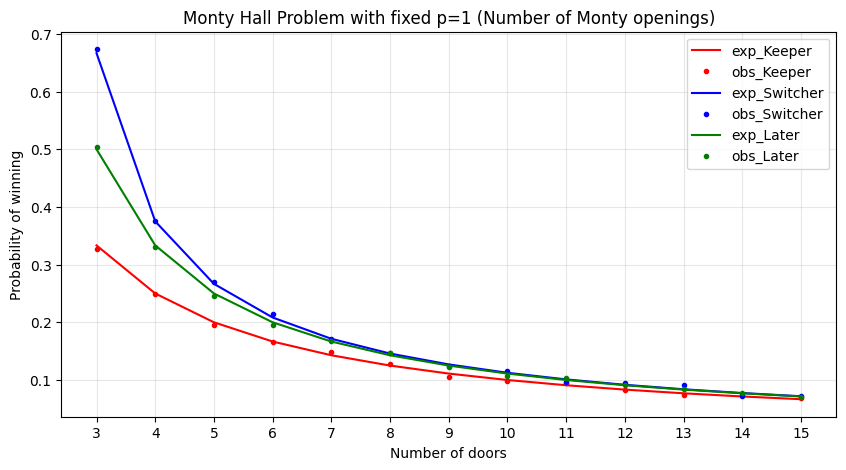

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(vec_N, vec_keeper_Pwins, "-r", label="exp_Keeper")
plt.plot(vec_N, vec_keeper, ".r", label="obs_Keeper")
plt.plot(vec_N, vec_switcher_Pwins, "-b", label="exp_Switcher")
plt.plot(vec_N, vec_switcher, ".b", label="obs_Switcher")
plt.plot(vec_N, vec_later_Pwins, "-g", label="exp_Later")
plt.plot(vec_N, vec_later, ".g", label="obs_Later")
plt.legend()
plt.xticks(vec_N)
plt.xlabel("Number of doors")
plt.ylabel("Probability of winning")
plt.title(f'Monty Hall Problem with fixed p={p} (Number of Monty openings)')
plt.grid(alpha=0.3)
plt.show()

In [11]:
vec_keeper = []
vec_switcher = []
vec_later = []
p = 3

for N in range(5, 16):

    keeper_wins = 0
    switcher_wins = 0
    later_wins = 0
    rounds = 10000

    for i in range(rounds):

      vec_game = np.zeros(N)
      win = np.random.randint(0,N)
      vec_game[win] = 1

      first_choice = np.random.randint(0,N)

      monty_opens = np.random.choice(N, size=p, replace=False)
      while(first_choice in monty_opens or win in monty_opens):
        monty_opens = np.random.choice(N, size=p, replace=False)

      second_choice = np.random.randint(0,N)
      while(second_choice == first_choice or second_choice in monty_opens):
        second_choice = np.random.randint(0,N)

      third_choice = np.random.randint(0,N)
      while(third_choice in monty_opens):
        third_choice = np.random.randint(0,N)

      keeper = first_choice
      switcher = second_choice
      later = third_choice

      if(keeper == win):
        keeper_wins += 1
      if(switcher == win):
        switcher_wins += 1
      if(later == win):
        later_wins += 1

    vec_keeper.append(keeper_wins/rounds)
    vec_switcher.append(switcher_wins/rounds)
    vec_later.append(later_wins/rounds)

In [12]:
vec_N = np.arange(5, 16)
vec_keeper_Pwins = 1/vec_N
vec_switcher_Pwins = (1/(vec_N))*((vec_N-1)/(vec_N-p-1))
vec_later_Pwins = 1/(vec_N-p)

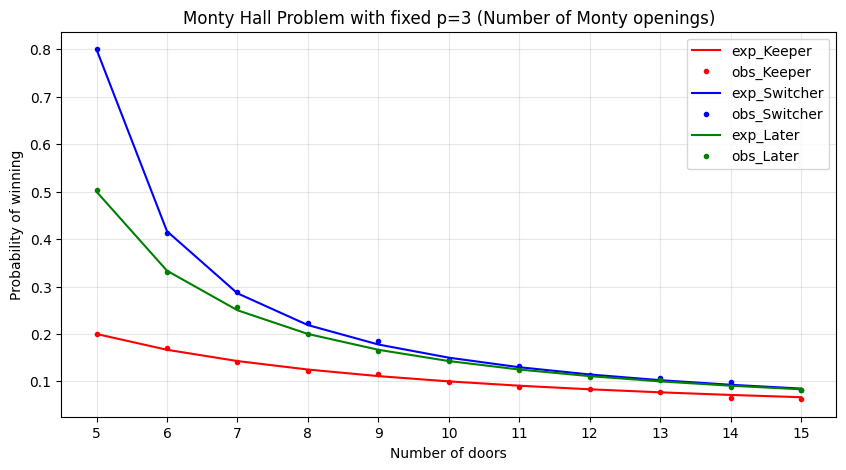

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(vec_N, vec_keeper_Pwins, "-r", label="exp_Keeper")
plt.plot(vec_N, vec_keeper, ".r", label="obs_Keeper")
plt.plot(vec_N, vec_switcher_Pwins, "-b", label="exp_Switcher")
plt.plot(vec_N, vec_switcher, ".b", label="obs_Switcher")
plt.plot(vec_N, vec_later_Pwins, "-g", label="exp_Later")
plt.plot(vec_N, vec_later, ".g", label="obs_Later")
plt.legend()
plt.xticks(vec_N)
plt.xlabel("Number of doors")
plt.ylabel("Probability of winning")
plt.title(f'Monty Hall Problem with fixed p={p} (Number of Monty openings)')
plt.grid(alpha=0.3)
plt.show()

In [14]:
new_vec_keeper = []
new_vec_switcher = []
new_vec_later = []
N = 15

for p in range(1, N-1):

    keeper_wins = 0
    switcher_wins = 0
    later_wins = 0
    rounds = 10000

    for i in range(rounds):

      vec_game = np.zeros(N)
      win = np.random.randint(0,N)
      vec_game[win] = 1

      first_choice = np.random.randint(0,N)

      monty_opens = np.random.choice(N, size=p, replace=False)
      while(first_choice in monty_opens or win in monty_opens):
        monty_opens = np.random.choice(N, size=p, replace=False)

      second_choice = np.random.randint(0,N)
      while(second_choice == first_choice or second_choice in monty_opens):
        second_choice = np.random.randint(0,N)

      third_choice = np.random.randint(0,N)
      while(third_choice in monty_opens):
        third_choice = np.random.randint(0,N)

      keeper = first_choice
      switcher = second_choice
      later = third_choice

      if(keeper == win):
        keeper_wins += 1
      if(switcher == win):
        switcher_wins += 1
      if(later == win):
        later_wins += 1

    new_vec_keeper.append(keeper_wins/rounds)
    new_vec_switcher.append(switcher_wins/rounds)
    new_vec_later.append(later_wins/rounds)

In [15]:
vec_p = np.arange(1, N-1)
keeper_Pwins = win_prob("keeper", N, vec_p)
switcher_Pwins = win_prob("switcher", N, vec_p)
later_Pwins = win_prob("later", N, vec_p)

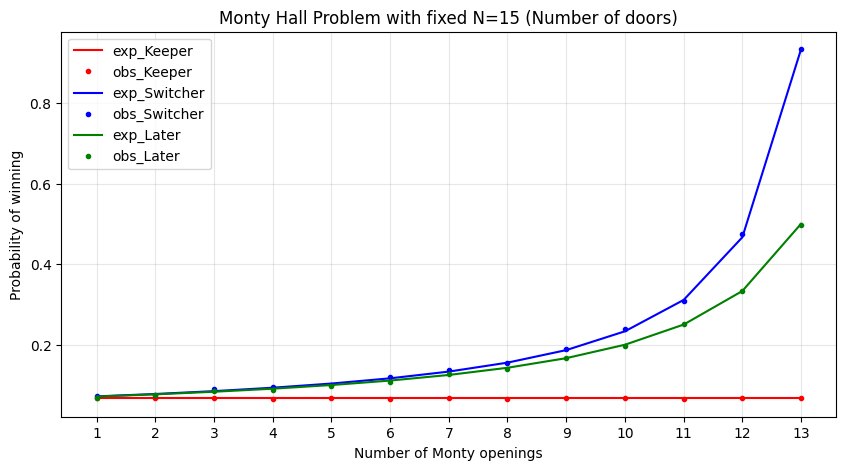

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(vec_p, keeper_Pwins*np.ones(len(vec_p)), "-r", label="exp_Keeper")
plt.plot(vec_p, new_vec_keeper, ".r", label="obs_Keeper")
plt.plot(vec_p, switcher_Pwins, "-b", label="exp_Switcher")
plt.plot(vec_p, new_vec_switcher, ".b", label="obs_Switcher")
plt.plot(vec_p, later_Pwins, "-g", label="exp_Later")
plt.plot(vec_p, new_vec_later, ".g", label="obs_Later")
plt.legend()
plt.xticks(vec_p)
plt.xlabel("Number of Monty openings")
plt.ylabel("Probability of winning")
plt.title(f'Monty Hall Problem with fixed N={N} (Number of doors)')
plt.grid(alpha=0.3)
plt.show()